# Exploratory Data Analysis

This notebook explores the distributions and relationships within the obesity-risk dataset.

## Objectives

- Analyse numerical feature distributions
- Examine categorical feature frequencies
- Compare features with obesity-risk classes
- Identify skewness, outliers, and unusual patterns
- Understand relationships before preprocessing and modelling

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20758, 18)


In [13]:
identifier_column = "id"
target_column = "NObeyesdad"

numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS",
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 8
Categorical features: 8


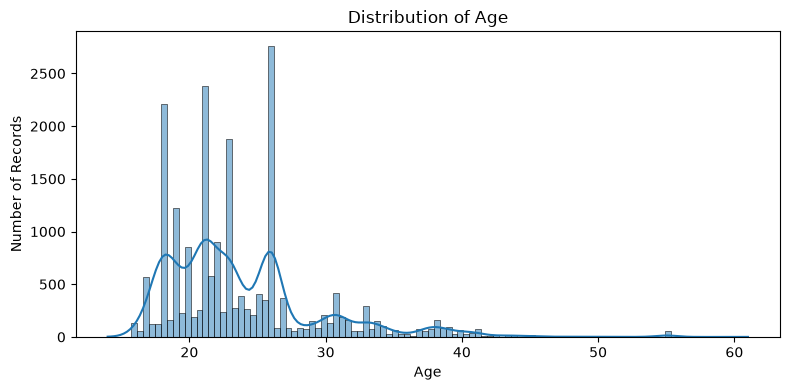

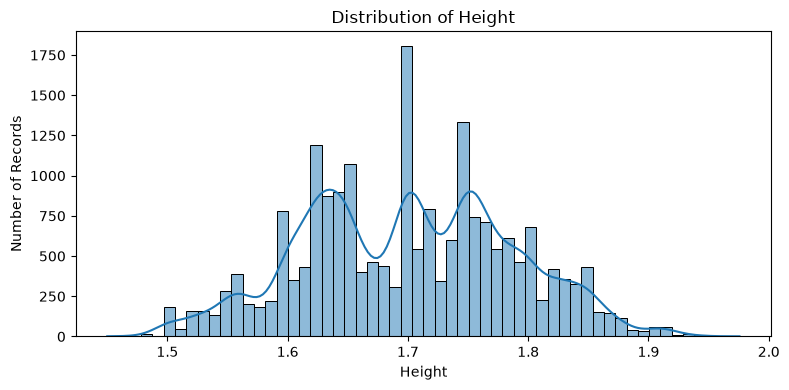

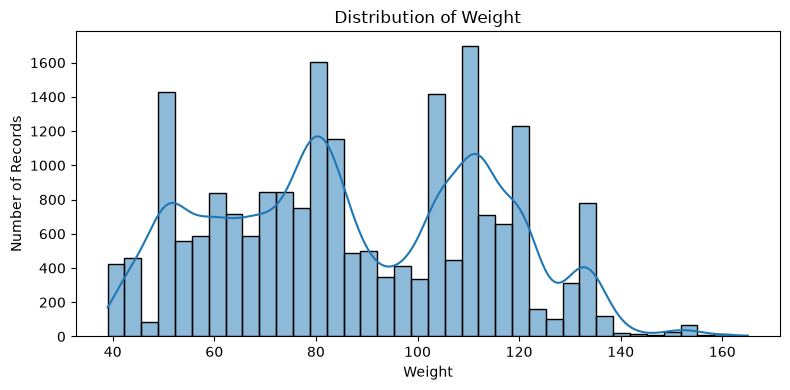

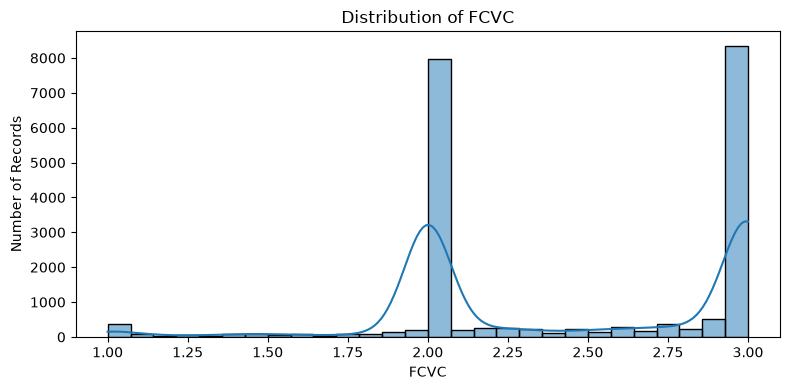

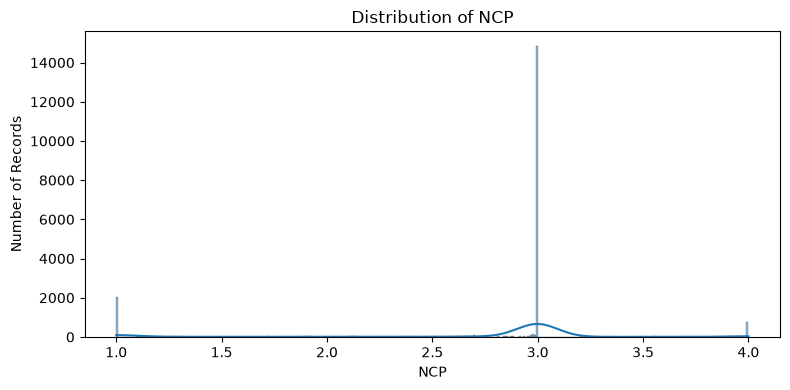

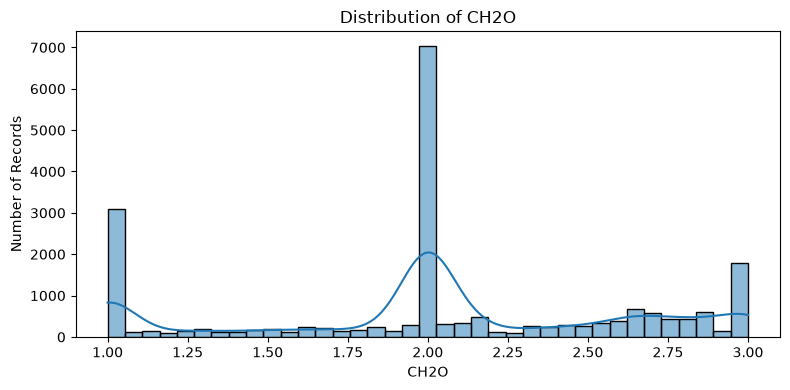

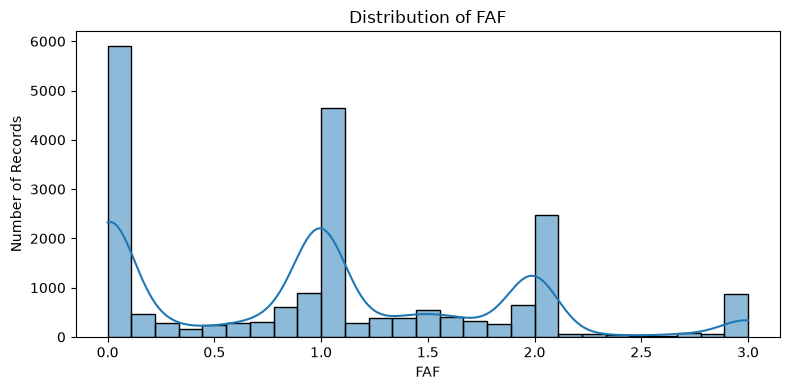

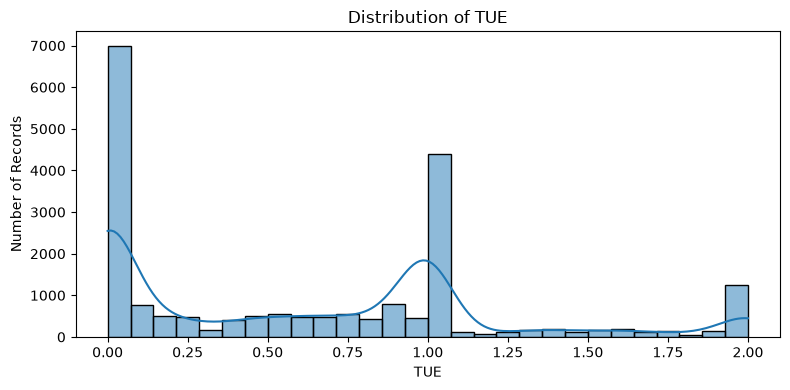

In [14]:
for column in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

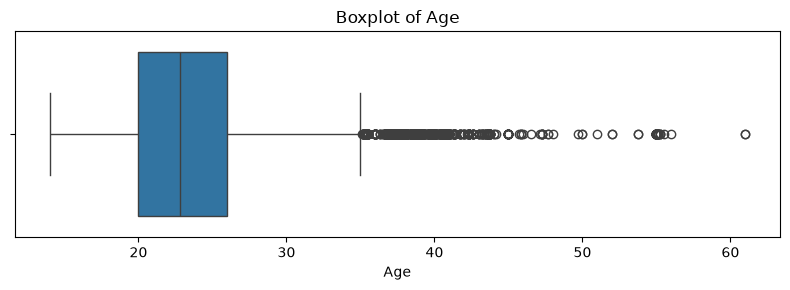

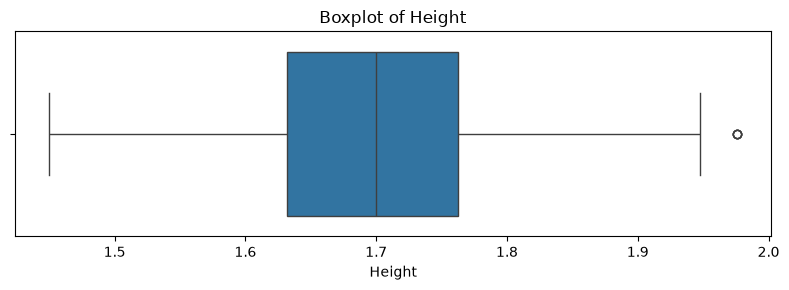

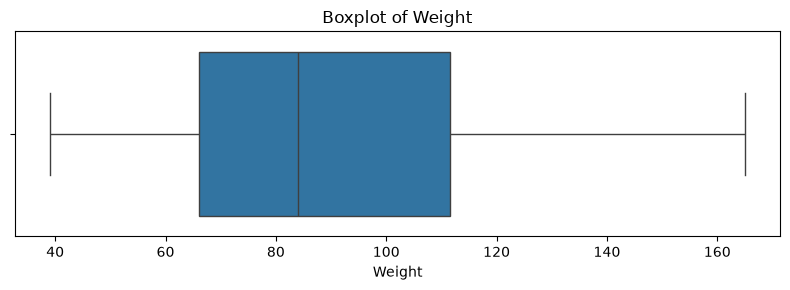

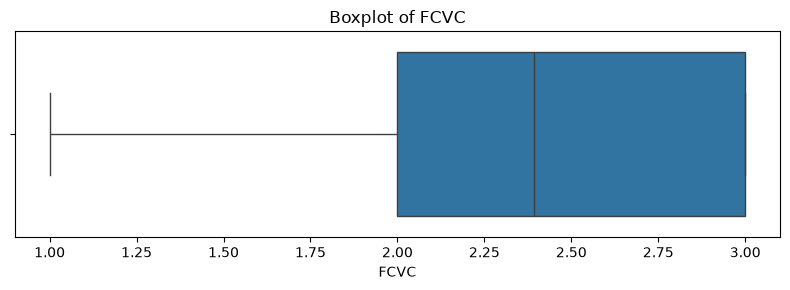

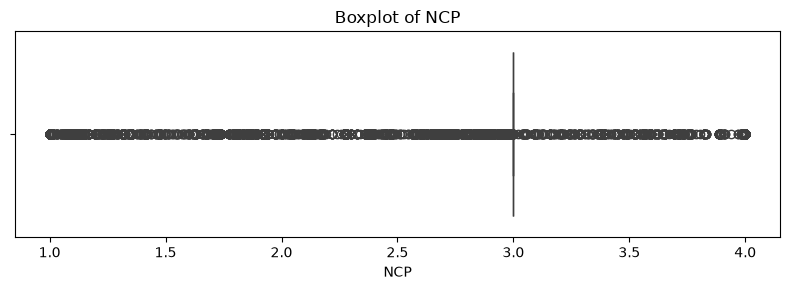

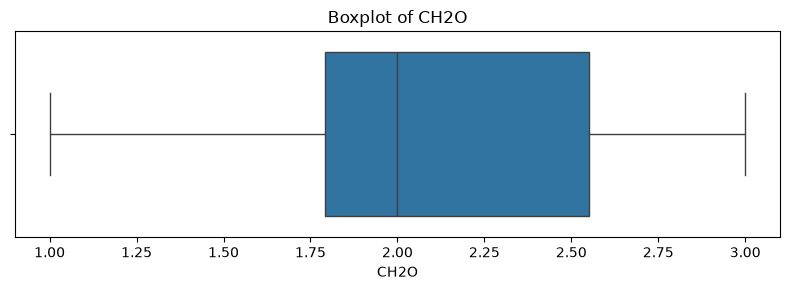

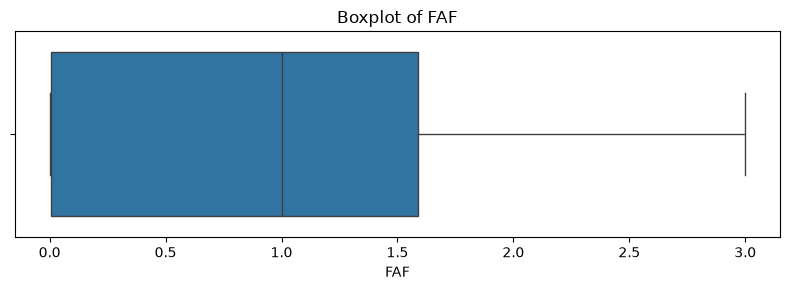

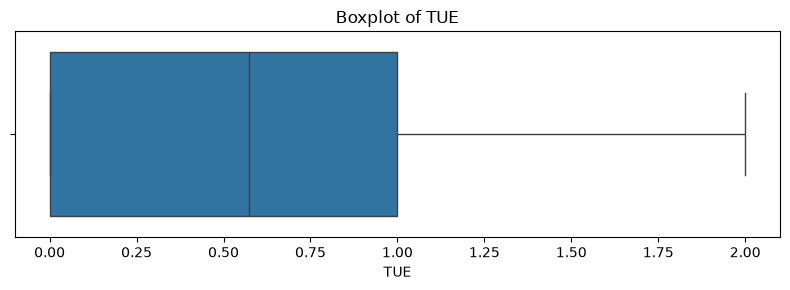

In [15]:
for column in numerical_features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column,
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [16]:
for column in categorical_features:
    category_counts = df[column].value_counts()
    category_percentages = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    category_summary = pd.DataFrame({
        "Count": category_counts,
        "Percentage": category_percentages,
    })

    print(f"\n{column}")
    print("-" * len(column))
    display(category_summary)


Gender
------


,Count,Percentage
Gender,,
Female,10422,50.21
Male,10336,49.79



family_history_with_overweight
------------------------------


,Count,Percentage
family_history_with_overweight,,
yes,17014,81.96
no,3744,18.04



FAVC
----


...

,Count,Percentage
SCC,,
no,20071,96.69
yes,687,3.31



CALC
----


,Count,Percentage
CALC,,
Sometimes,15066,72.58
no,5163,24.87
Frequently,529,2.55



MTRANS
------


,Count,Percentage
MTRANS,,
Public_Transportation,16687,80.39
Automobile,3534,17.02
Walking,467,2.25
Motorbike,38,0.18
Bike,32,0.15


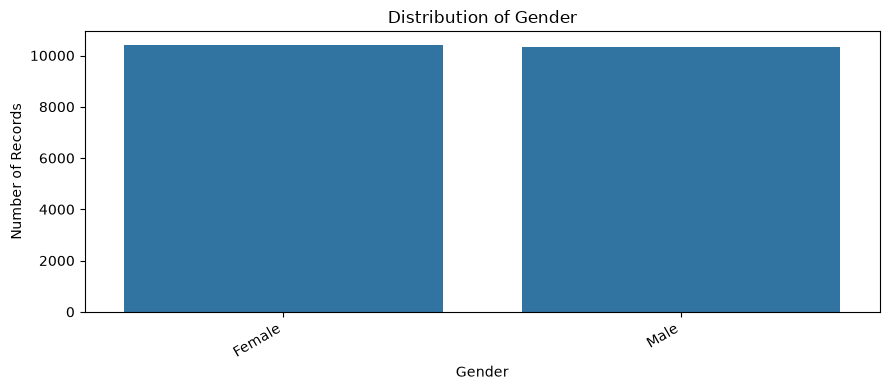

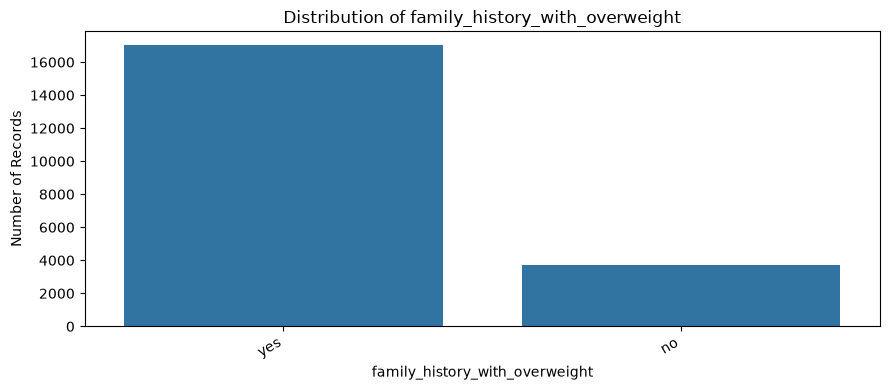

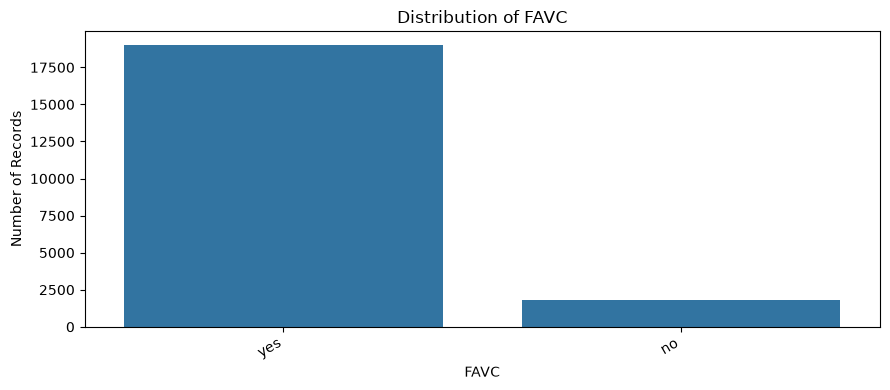

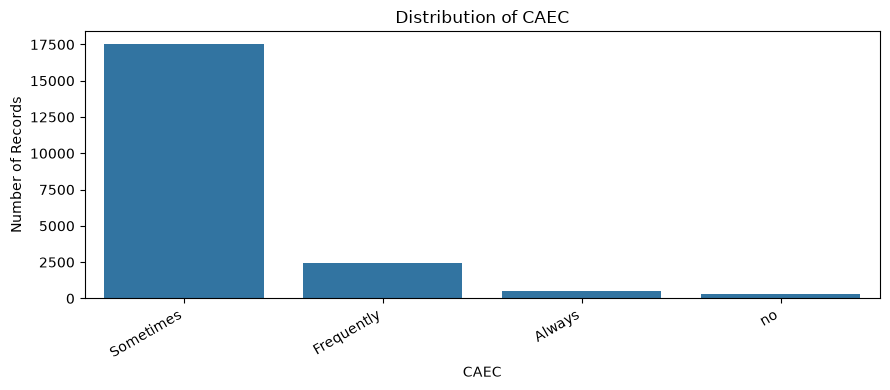

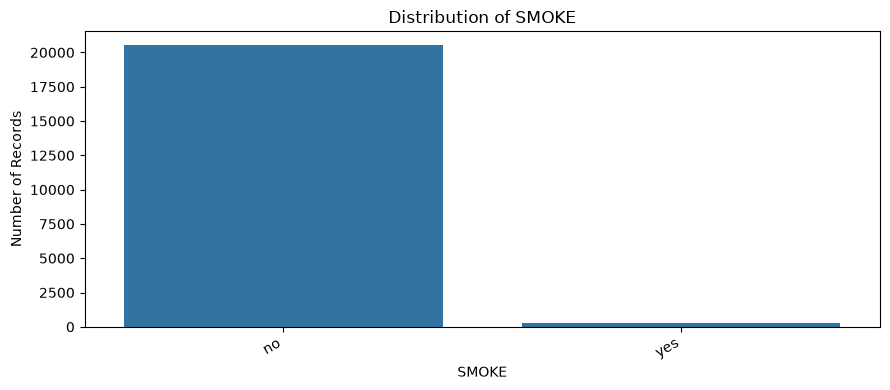

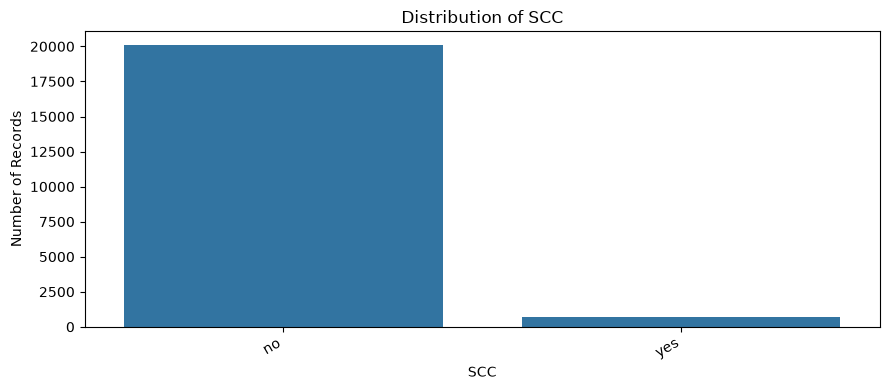

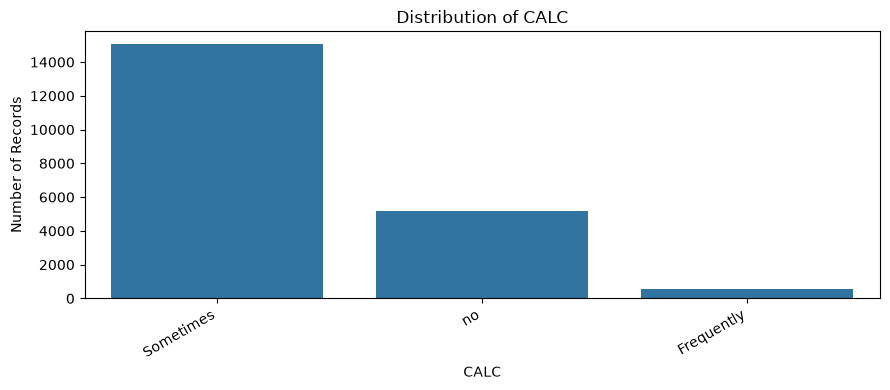

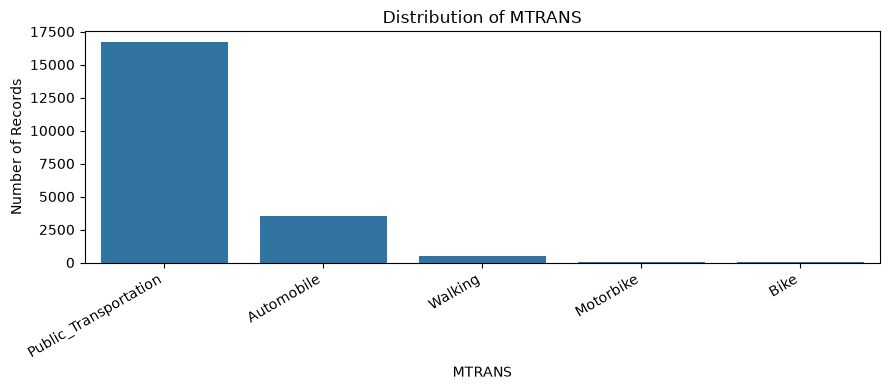

In [17]:
for column in categorical_features:
    category_order = df[column].value_counts().index

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=df,
        x=column,
        order=category_order,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [8]:
category_extremes = []

for column in categorical_features:
    counts = df[column].value_counts()

    category_extremes.append({
        "Feature": column,
        "Most common category": counts.idxmax(),
        "Most common count": counts.max(),
        "Least common category": counts.idxmin(),
        "Least common count": counts.min(),
    })

category_extremes_df = pd.DataFrame(category_extremes)

category_extremes_df

,Feature,Most common category,Most common count,Least common category,Least common count
0,Gender,Female,10422,Male,10336
1,family_history_with_overweight,yes,17014,no,3744
2,FAVC,yes,18982,no,1776
3,CAEC,Sometimes,17529,no,279
4,SMOKE,no,20513,yes,245
5,SCC,no,20071,yes,687
6,CALC,Sometimes,15066,Frequently,529
7,MTRANS,Public_Transportation,16687,Bike,32


In [9]:
category_concentration = []

for column in categorical_features:
    most_common_percentage = (
        df[column]
        .value_counts(normalize=True)
        .max()
        * 100
    )

    category_concentration.append({
        "Feature": column,
        "Largest category percentage": round(
            most_common_percentage,
            2,
        ),
    })

category_concentration_df = pd.DataFrame(
    category_concentration
).sort_values(
    by="Largest category percentage",
    ascending=False,
)

category_concentration_df

,Feature,Largest category percentage
4,SMOKE,98.82
5,SCC,96.69
2,FAVC,91.44
3,CAEC,84.44
1,family_history_with_overweight,81.96
7,MTRANS,80.39
6,CALC,72.58
0,Gender,50.21


In [18]:

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "obesity.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)

df.head()

Project root: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System
Dataset path: /Users/paveepiru/Desktop/Obesity-Risk-Intelligence-System/data/raw/obesity.csv
File exists: True


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

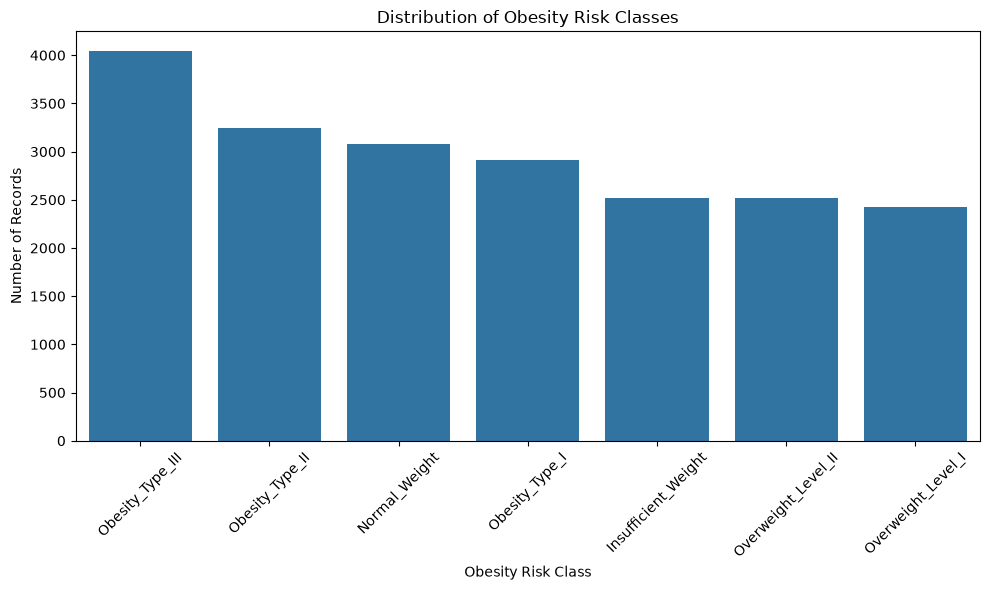

In [20]:
# Target class distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=df[target_column].value_counts().index
)

plt.title("Distribution of Obesity Risk Classes")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

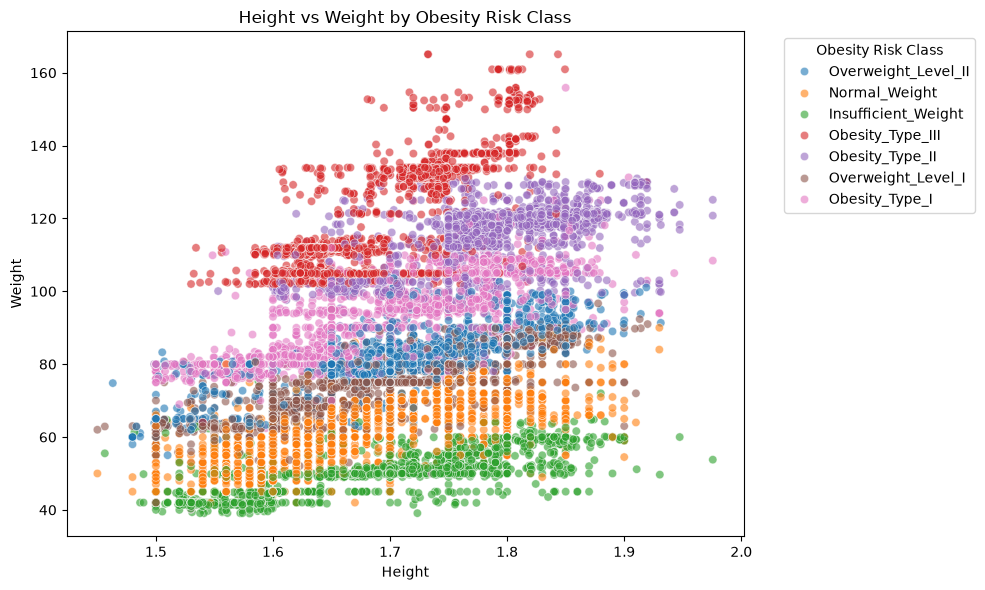

In [21]:
# Height vs Weight relationship

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue=target_column,
    alpha=0.6
)

plt.title("Height vs Weight by Obesity Risk Class")
plt.xlabel("Height")
plt.ylabel("Weight")

plt.legend(
    title="Obesity Risk Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

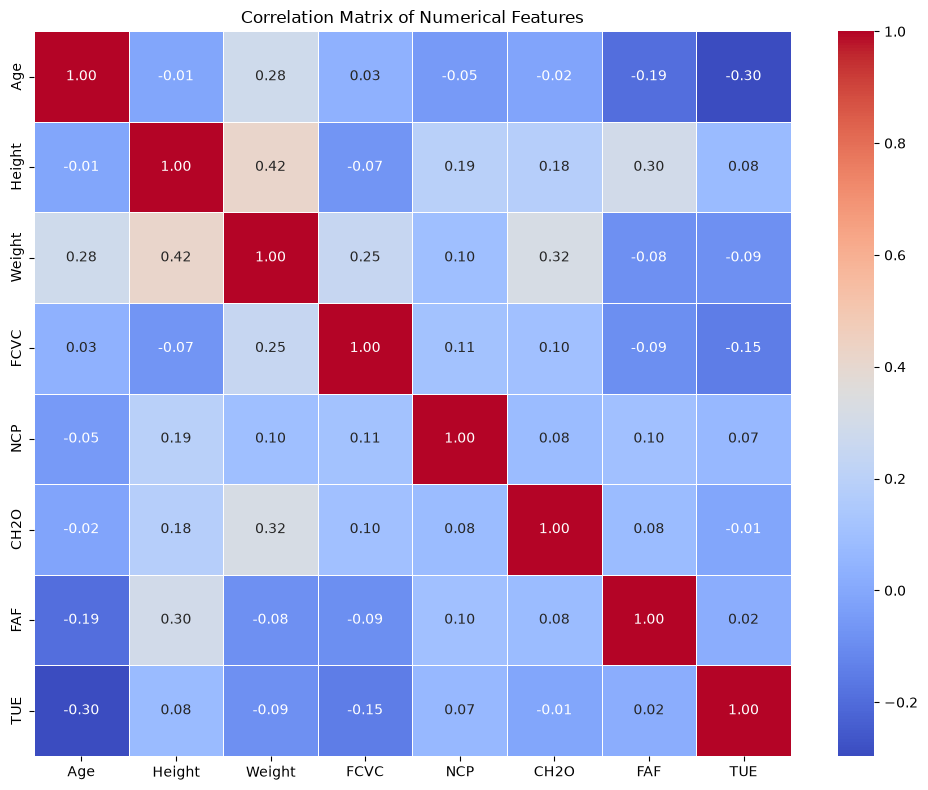

In [22]:
# Correlation analysis

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## EDA Findings

- The dataset contains seven obesity-risk classes, and the target class distribution is not perfectly balanced.
- The numerical feature distributions show different ranges and patterns across the dataset.
- The Height vs Weight scatter plot shows variation in weight across different height values and differences in the distribution of obesity-risk classes.
- Among the numerical features, Height and Weight have the strongest positive correlation (r = 0.417).
- Weight also shows positive correlations with CH2O (r = 0.318) and Age (r = 0.283).
- TUE and Age show a negative correlation (r = -0.296).
- These EDA findings provide useful information for the preprocessing and machine learning stages.